# 04 — Analysis

In [1]:
from notebook_utils import ensure_repo_root
ensure_repo_root()

WindowsPath('C:/Github/higher-education-outcomes-analysis')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from src.utils.text import to_title_case
from src.utils.data_utils import load_data, set_pandas_display_options

df = load_data("processed")

# Set pandas display options for better readability
set_pandas_display_options()

In [3]:
def rate_groups(
        df: pd.DataFrame, 
        rate_col: str,
        groupby: str | list[str],
        sort: bool = True, 
        obs: bool = True, 
        show: bool = True
) -> pd.DataFrame:
    
    results = df.groupby(groupby, observed=obs)[rate_col].agg(["count", "mean", "std"]).reset_index()
    if sort:
        results.sort_values("mean", ascending=False, inplace=True)
    if show: display(results)
    return results

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   course_name                 297 non-null    object 
 1   section                     297 non-null    int64  
 2   total_enrollment            297 non-null    int64  
 3   dropout_count               297 non-null    int64  
 4   insufficient_count          297 non-null    int64  
 5   free_status_count           297 non-null    int64  
 6   promoted_completion_count   297 non-null    int64  
 7   regular_completion_count    297 non-null    int64  
 8   course_code                 297 non-null    object 
 9   program_code                297 non-null    object 
 10  is_reconciled               297 non-null    bool   
 11  reconciled_enrollment_diff  297 non-null    int64  
 12  workload                    297 non-null    Int64  
 13  shift                       297 non

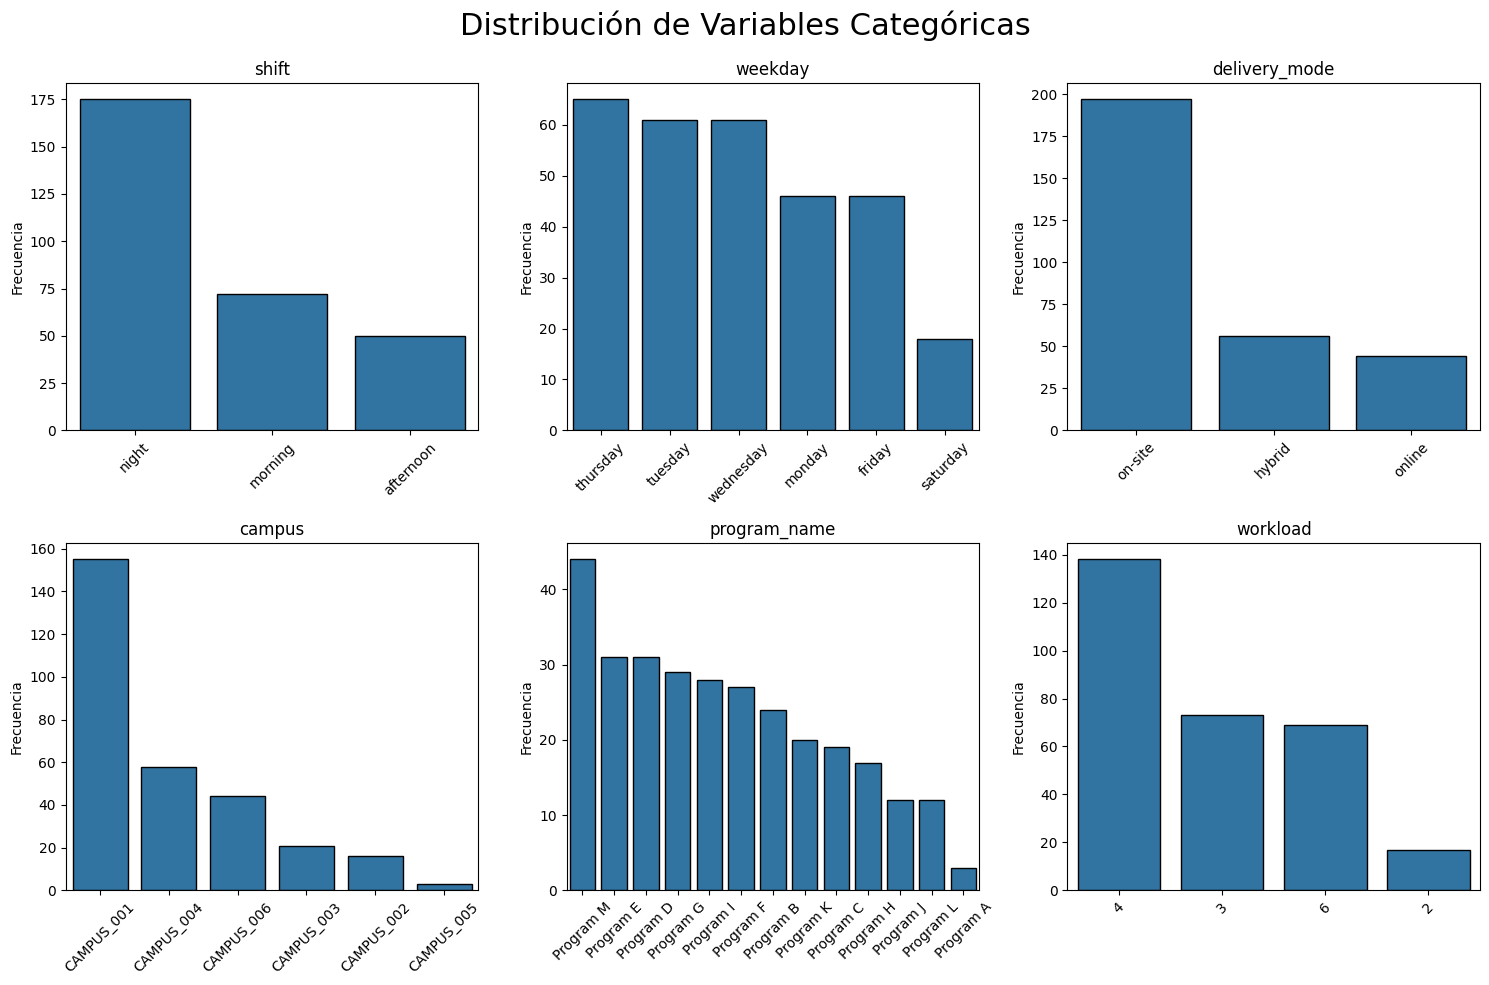

In [5]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro por cantidad de categorías
]
cat_cols += ["workload"]
cat_cols.remove("program_code")

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        x=col,
        order=order,
        dodge=False,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=22)
plt.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

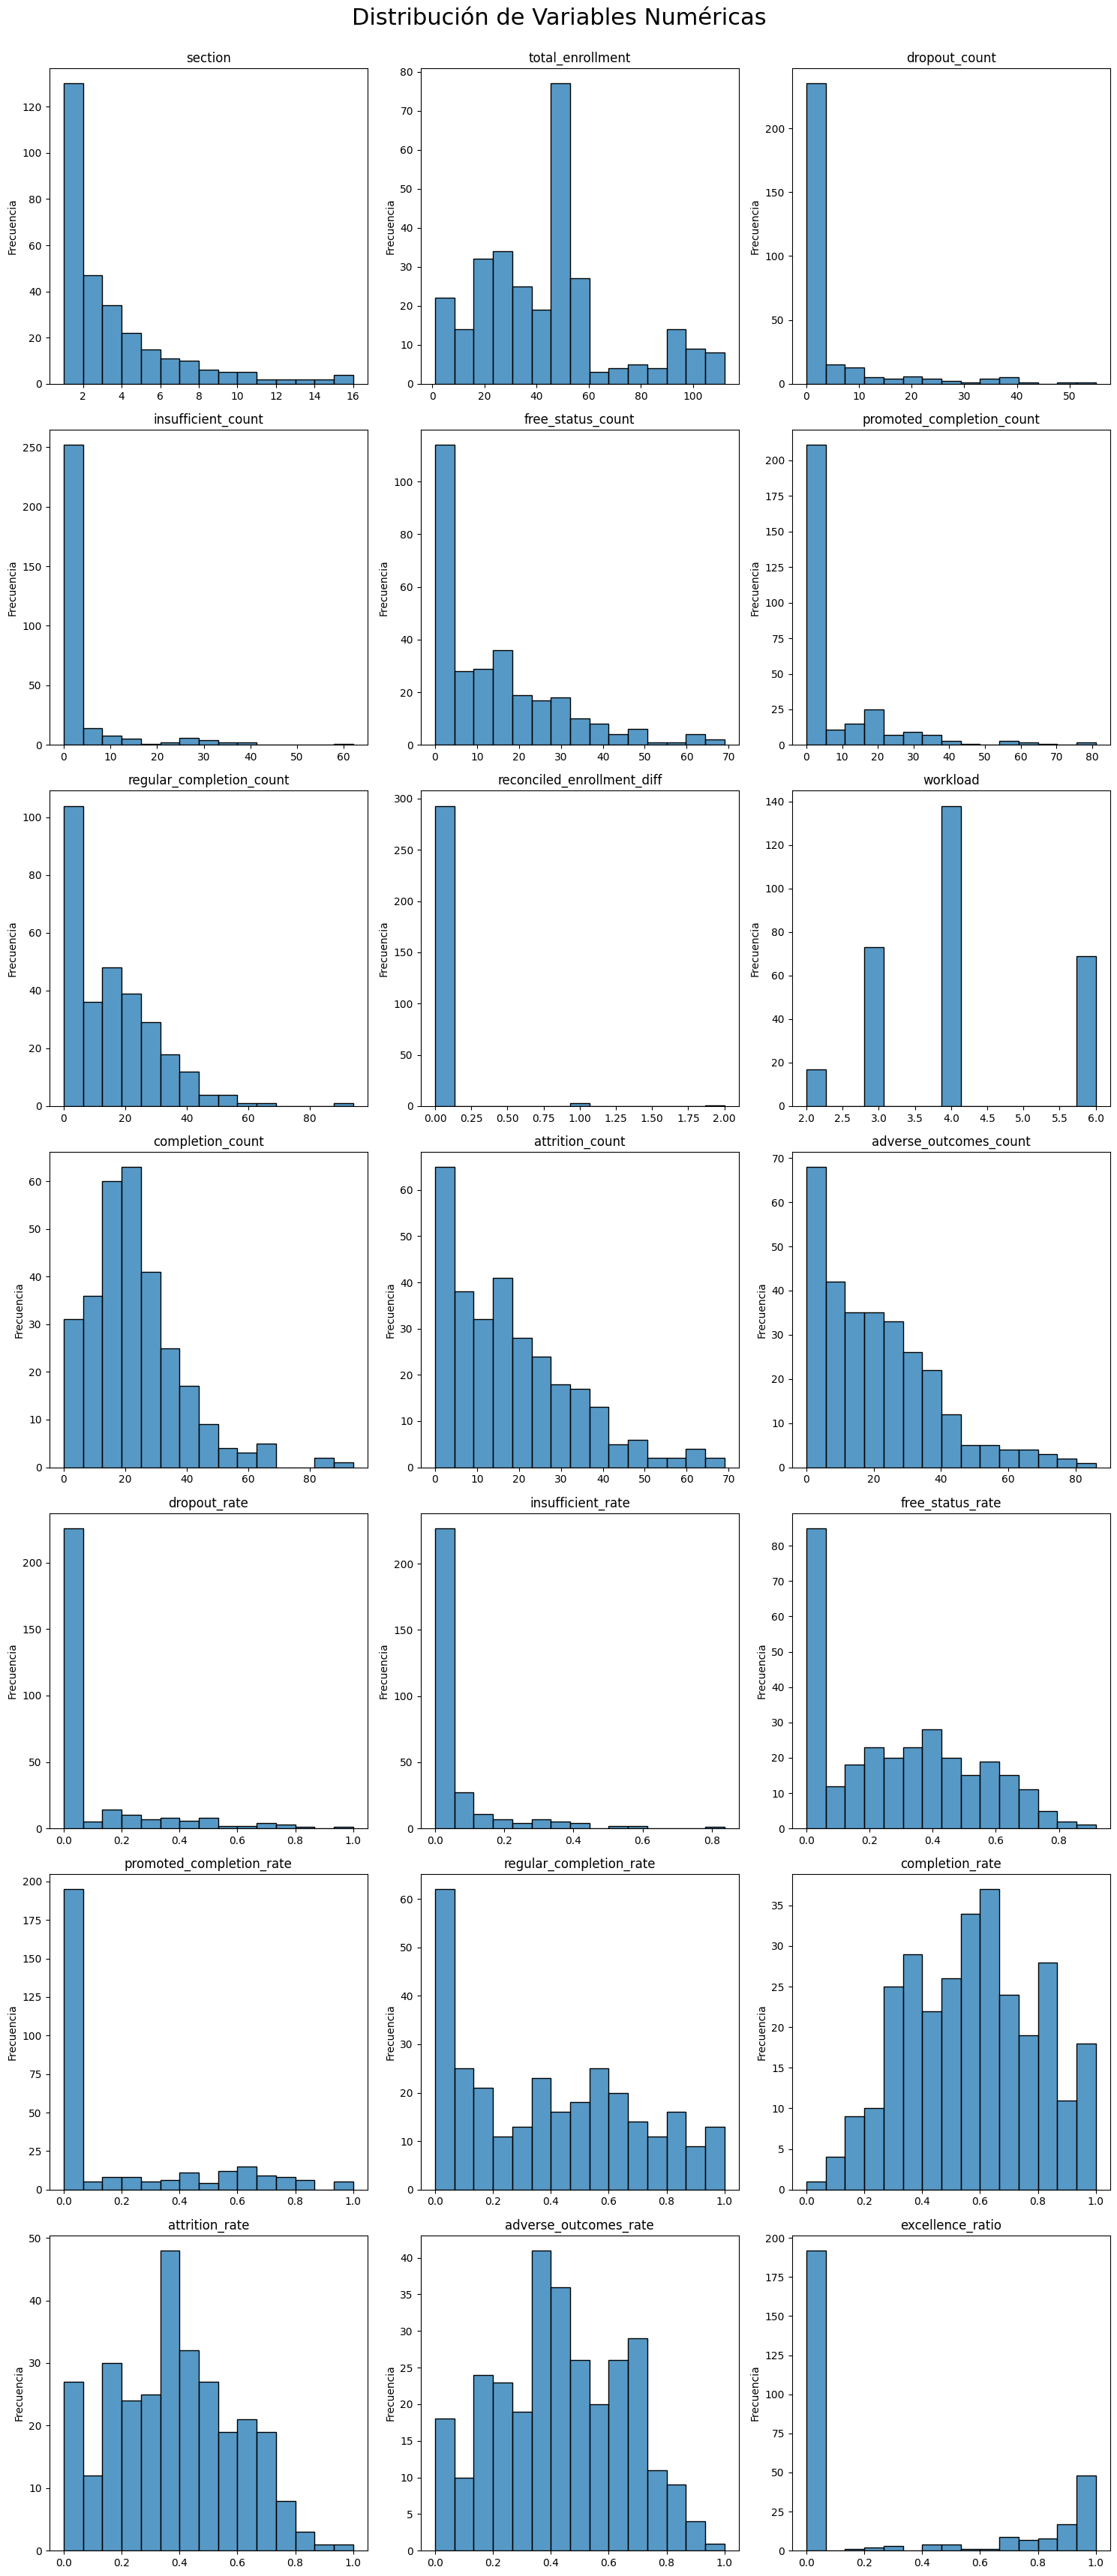

In [6]:
# seleccionar variables numéricas
int_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    
    sns.histplot(data=df, x=col, bins=15, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Numéricas", fontsize=22)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

a realizar:
* rates por carrera, cursos con mayor abandono, promoted
* correlación entre workload y rates
* rates entre shifts
* rates entre deliveries
* rates por campus
* rates entre weekday
* heatmap de correlaciones entre numéricas

In [7]:
rate_cols = df.select_dtypes(include=[np.number]).columns
rate_cols = rate_cols[rate_cols.str.endswith(("_rate", "_ratio"))]
rate_cols

Index(['dropout_rate', 'insufficient_rate', 'free_status_rate', 'promoted_completion_rate', 'regular_completion_rate', 'completion_rate',
       'attrition_rate', 'adverse_outcomes_rate', 'excellence_ratio'],
      dtype='object')

## Rates by program

In [8]:
rates_by_program = df.groupby("program_name")[rate_cols].agg(["count", "mean", "std"])
rates_by_program

dropout_rate           insufficient_rate           free_status_rate           promoted_completion_rate            \
                    count mean  std             count mean  std            count mean  std                    count mean  std   
program_name                                                                                                                    
Program A               3 0.24 0.42                 3 0.03 0.05                3 0.21 0.19                        3 0.09 0.16   
Program B              24 0.09 0.17                24 0.11 0.14               24 0.22 0.18                       24 0.16 0.23   
Program C              19 0.08 0.19                19 0.06 0.12               19 0.34 0.23                       19 0.19 0.28   
Program D              31 0.13 0.25                31 0.07 0.14               31 0.27 0.24                       31 0.20 0.32   
Program E              31 0.08 0.15                31 0.05 0.13               31 0.30 0.26                       31 0.13 0.27   
Program F              27 0.04 0.17                27 0.03 0.08               27 0.39 0.24                       27 0.11 0.22   
Program G              29 0.12 0.17                29 0.03 0.11               29 0.19 0.23                       29 0.26 0.33   
Program H              17 0.10 0.20                17 0.08 0.13               17 0.33 0.23                       17 0.18 0.25   
Program I              28 0.07 0.15                28 0.08 0.17               28 0.21 0.20                       28 0.14 0.28   
Program J              12 0.01 0.04                12 0.01 0.03               12 0.38 0.32                       12 0.24 0.34   
Program K              20 0.12 0.22                20 0.07 0.11               20 0.24 0.24                       20 0.15 0.28   
Program L              12 0.17 0.28                12 0.01 0.01               12 0.24 0.27                       12 0.32 0.31   
Program M              44 0.06 0.14                44 0.04 0.09               44 0.35 0.23                       44 0.17 0.28   

             regular_completion_rate           completion_rate           attrition_rate           adverse_outcomes_rate            \
                               count mean  std           count mean  std          count mean  std                 count mean  std   
program_name                                                                                                                        
Program A                          3 0.43 0.38               3 0.52 0.22              3 0.45 0.25                     3 0.48 0.22   
Program B                         24 0.44 0.29              24 0.59 0.17             24 0.30 0.16                    24 0.41 0.17   
Program C                         19 0.33 0.30              19 0.52 0.23             19 0.42 0.20                    19 0.48 0.23   
Program D                         31 0.33 0.27              31 0.53 0.22             31 0.40 0.22                    31 0.47 0.22   
Program E                         31 0.45 0.34              31 0.58 0.26             31 0.37 0.24                    31 0.42 0.26   
Program F                         27 0.42 0.31              27 0.54 0.23             27 0.43 0.22                    27 0.46 0.23   
Program G                         29 0.39 0.35              29 0.66 0.20             29 0.31 0.19                    29 0.34 0.20   
Program H                         17 0.32 0.32              17 0.49 0.23             17 0.43 0.19                    17 0.51 0.23   
Program I                         28 0.49 0.29              28 0.64 0.21             28 0.28 0.20                    28 0.36 0.21   
Program J                         12 0.36 0.33              12 0.60 0.31             12 0.39 0.31                    12 0.40 0.31   
Program K                         20 0.41 0.31              20 0.56 0.24             20 0.36 0.22                    20 0.44 0.24   
Program L                         12 0.26 0.36              12 0.59 0.27             1

### Dropout

In [9]:
dropout_by_program = rates_by_program.loc[:, "dropout_rate"].reset_index().sort_values("mean", ascending=False)
dropout_by_program

,program_name,count,mean,std
0,Program A,3,0.24,0.42
11,Program L,12,0.17,0.28
3,Program D,31,0.13,0.25
10,Program K,20,0.12,0.22
6,Program G,29,0.12,0.17
7,Program H,17,0.10,0.20
1,Program B,24,0.09,0.17
2,Program C,19,0.08,0.19
4,Program E,31,0.08,0.15
8,Program I,28,0.07,0.15


### Attrition

In [10]:
attrition_by_program = rates_by_program.loc[:, "attrition_rate"].reset_index().sort_values("mean", ascending=False)
attrition_by_program

,program_name,count,mean,std
0,Program A,3,0.45,0.25
5,Program F,27,0.43,0.22
7,Program H,17,0.43,0.19
2,Program C,19,0.42,0.20
11,Program L,12,0.41,0.27
12,Program M,44,0.41,0.19
3,Program D,31,0.40,0.22
9,Program J,12,0.39,0.31
4,Program E,31,0.37,0.24
10,Program K,20,0.36,0.22


### Completion

In [11]:
completion_by_program = rates_by_program.loc[:, "completion_rate"].reset_index().sort_values("mean", ascending=False)
completion_by_program

,program_name,count,mean,std
6,Program G,29,0.66,0.20
8,Program I,28,0.64,0.21
9,Program J,12,0.60,0.31
1,Program B,24,0.59,0.17
11,Program L,12,0.59,0.27
4,Program E,31,0.58,0.26
10,Program K,20,0.56,0.24
12,Program M,44,0.55,0.20
5,Program F,27,0.54,0.23
3,Program D,31,0.53,0.22


### Excellence

In [12]:
excellence_by_program = rates_by_program.loc[:, "excellence_ratio"].reset_index().sort_values("mean", ascending=False)
excellence_by_program

,program_name,count,mean,std
11,Program L,12,0.53,0.48
6,Program G,29,0.40,0.46
7,Program H,17,0.37,0.47
2,Program C,19,0.34,0.44
0,Program A,3,0.33,0.58
9,Program J,12,0.33,0.41
3,Program D,31,0.30,0.45
1,Program B,24,0.29,0.38
12,Program M,44,0.26,0.40
10,Program K,20,0.26,0.40


## Correlation

In [13]:
target_col = "completion_rate"

In [14]:
corr_cols = ["section", "total_enrollment", "workload"] + rate_cols.tolist()
corr_cols.remove(target_col)
corr_cols

['section',
 'total_enrollment',
 'workload',
 'dropout_rate',
 'insufficient_rate',
 'free_status_rate',
 'promoted_completion_rate',
 'regular_completion_rate',
 'attrition_rate',
 'adverse_outcomes_rate',
 'excellence_ratio']

In [15]:
from scipy.stats import spearmanr

results = []
for col in corr_cols:
    corr, p_value = spearmanr(df[col], df[target_col])
    results.append({
        "variable": col,
        "spearman_corr": corr,
        "p_value": p_value,
        "significant": p_value < 0.1
    })

spearman_top = (
    pd.DataFrame(results)
      .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
      .reset_index(drop=True)
)

print(f"Variables numéricas más correlacionadas con {target_col} (Spearman):")
spearman_top.head(20)

Variables numéricas más correlacionadas con completion_rate (Spearman):


,variable,spearman_corr,p_value,significant
0,adverse_outcomes_rate,-1.00,0.00,True
1,attrition_rate,-0.86,0.00,True
2,free_status_rate,-0.54,0.00,True
3,section,-0.43,0.00,True
4,regular_completion_rate,0.39,0.00,True
5,total_enrollment,-0.38,0.00,True
6,insufficient_rate,-0.35,0.00,True
7,promoted_completion_rate,0.15,0.01,True
8,dropout_rate,-0.10,0.08,True
9,excellence_ratio,0.09,0.14,False


## Rates by shift

### Completion

In [16]:
completion_by_shift = rate_groups(df, "completion_rate", "shift")

,shift,count,mean,std
2,night,175,0.61,0.23
1,morning,72,0.53,0.21
0,afternoon,50,0.51,0.21


## Rates by campus

### Completion

In [17]:
completion_by_campus = rate_groups(df, "completion_rate", "campus")

,campus,count,mean,std
4,CAMPUS_005,3,1.00,0.00
2,CAMPUS_003,21,0.68,0.26
1,CAMPUS_002,16,0.65,0.17
5,CAMPUS_006,44,0.59,0.20
3,CAMPUS_004,58,0.58,0.21
0,CAMPUS_001,155,0.53,0.22


## Rates by weekday

### Completion

In [18]:
completion_by_weekday = rate_groups(df, "completion_rate", "weekday")

,weekday,count,mean,std
1,monday,46,0.61,0.23
5,wednesday,61,0.59,0.23
0,friday,46,0.58,0.21
3,thursday,65,0.57,0.22
4,tuesday,61,0.54,0.24
2,saturday,18,0.49,0.22


## Rates by delivery mode

### Completion

In [19]:
completion_by_delivery_mode = rate_groups(df, "completion_rate", "delivery_mode")

,delivery_mode,count,mean,std
2,online,44,0.59,0.20
1,on-site,197,0.59,0.22
0,hybrid,56,0.49,0.24


a realizar:
* analizar los distintos completion rates por categoría (weekday, campus, shift y delivery_mode) para las distintas carreras, y ver si hay algún caso particular (una configuración carrera-modalidad(o campus, o shift o weekday) con una tasa muy alta o muy baja)